
# 02 - Supervised Modeling

## Dataset: hourlySteps_clean.csv

### Programación para la Ciencia de Datos

## Objetivo
Implementar múltiples modelos supervisados utilizando Scikit-learn para predecir el comportamiento de actividad física a partir de registros horarios de pasos.

---

## Indicadores de logro cubiertos
- Implementación de múltiples modelos supervisados.
- Uso de pipelines.
- Justificación técnica de algoritmos.
- Aplicación correcta de Scikit-learn.
- Código reproducible y modular.
- Comparación experimental de modelos.

---

## Contexto del Dataset
El dataset contiene información horaria relacionada con actividad física:

- Hora del día.
- Día de la semana.
- Indicador de fin de semana.
- Total de pasos registrados.

El objetivo será construir una variable categórica para clasificar niveles de actividad física.



# Importación de Librerías


In [1]:

# ========================================
# LIBRERÍAS
# ========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 42

sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



# Carga del Dataset


In [2]:

# ========================================
# CARGA DE DATOS
# ========================================

df = pd.read_csv("hourlySteps_clean.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(21273, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.428148
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.428148
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.428148
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.428148
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.428148



# Comprensión Inicial de Variables


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21273 entries, 0 to 21272
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                21273 non-null  float64
 1   ActivityHour      21273 non-null  object 
 2   StepTotal         21273 non-null  float64
 3   Hora              21273 non-null  int64  
 4   Dia               21273 non-null  object 
 5   FinDeSemana       21273 non-null  int64  
 6   StepTotal_scaled  21273 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB



# Creación de Variable Objetivo

Se construirá una variable categórica llamada:

- Low Activity
- Medium Activity
- High Activity

Esto permitirá transformar el problema en una tarea de clasificación supervisada.


In [4]:

# ========================================
# CREACIÓN VARIABLE OBJETIVO
# ========================================

def classify_activity(steps):

    if steps < 100:
        return "Low Activity"

    elif steps < 1000:
        return "Medium Activity"

    else:
        return "High Activity"

df['ActivityLevel'] = df['StepTotal'].apply(classify_activity)

df['ActivityLevel'].value_counts()


,count
ActivityLevel,
Low Activity,13060
Medium Activity,6569
High Activity,1644



# Visualización de la Variable Objetivo


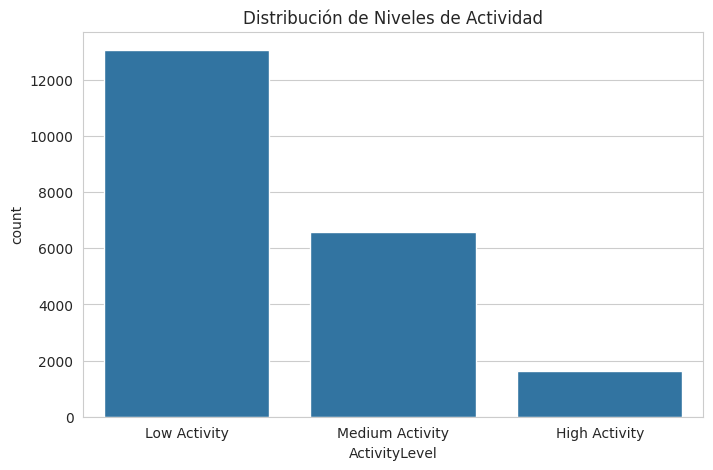

In [5]:

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ActivityLevel'
)

plt.title("Distribución de Niveles de Actividad")
plt.show()



# Selección de Variables Predictoras


In [6]:

# ========================================
# FEATURES Y TARGET
# ========================================

features = [
    'Hora',
    'FinDeSemana',
    'StepTotal_scaled'
]

X = df[features]

y = df['ActivityLevel']

print(X.head())


   Hora  FinDeSemana  StepTotal_scaled
0     0            1         -0.428148
1     1            1         -0.428148
2     2            1         -0.428148
3     3            1         -0.428148
4     4            1         -0.428148



# Codificación de la Variable Objetivo


In [7]:

# ========================================
# LABEL ENCODER
# ========================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)


['High Activity' 'Low Activity' 'Medium Activity']



# División Train/Test


In [8]:

# ========================================
# SPLIT
# ========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (17018, 3)
Test: (4255, 3)



# Construcción de Pipelines

Se utilizarán múltiples modelos supervisados para comparar rendimiento.


In [9]:

# ========================================
# MODELOS
# ========================================

models = {

    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ]),

    "Decision Tree": Pipeline([
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(random_state=RANDOM_STATE))
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=RANDOM_STATE))
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])
}

print("Pipelines creados.")


Pipelines creados.



# Entrenamiento de Modelos


In [10]:

# ========================================
# ENTRENAMIENTO
# ========================================

results = {}

for name, model in models.items():

    print("="*60)
    print(f"Entrenando modelo: {name}")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = {
        'model': model,
        'predictions': predictions,
        'accuracy': accuracy
    }

    print(f"Accuracy: {accuracy:.4f}")


Entrenando modelo: Logistic Regression
Accuracy: 0.9941
Entrenando modelo: Decision Tree
Accuracy: 1.0000
Entrenando modelo: Random Forest
Accuracy: 1.0000
Entrenando modelo: SVM
Accuracy: 0.9937
Entrenando modelo: KNN
Accuracy: 0.9955



# Comparación de Accuracy


In [11]:

# ========================================
# TABLA DE RESULTADOS
# ========================================

results_df = pd.DataFrame({
    model: results[model]['accuracy']
    for model in results.keys()
}, index=['Accuracy']).T

results_df.sort_values(
    by='Accuracy',
    ascending=False
)


,Accuracy
Decision Tree,1.000000
Random Forest,1.000000
KNN,0.995535
Logistic Regression,0.994125
SVM,0.993655


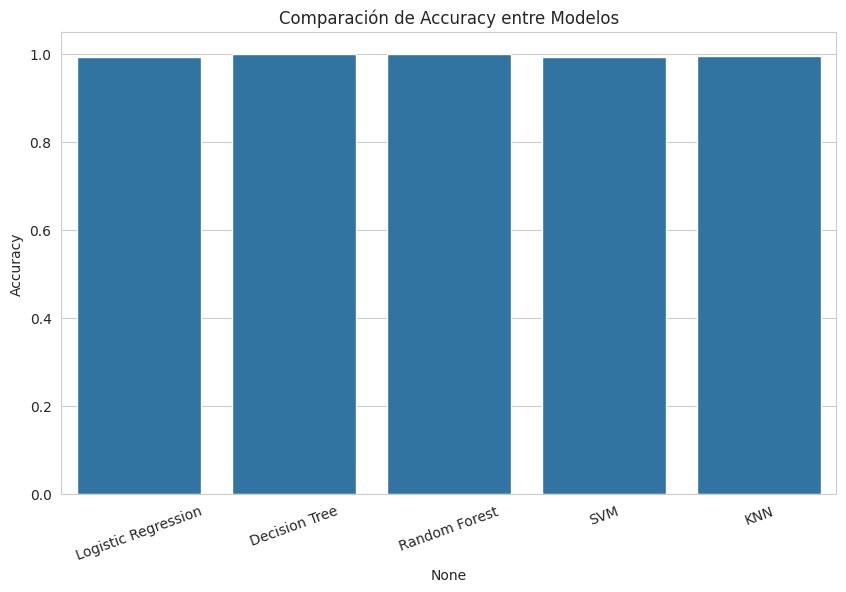

In [12]:

plt.figure(figsize=(10,6))

sns.barplot(
    x=results_df.index,
    y=results_df['Accuracy']
)

plt.title("Comparación de Accuracy entre Modelos")

plt.xticks(rotation=20)

plt.show()



# Matrices de Confusión


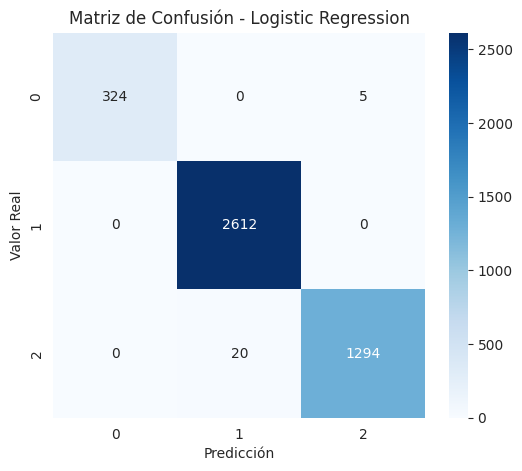

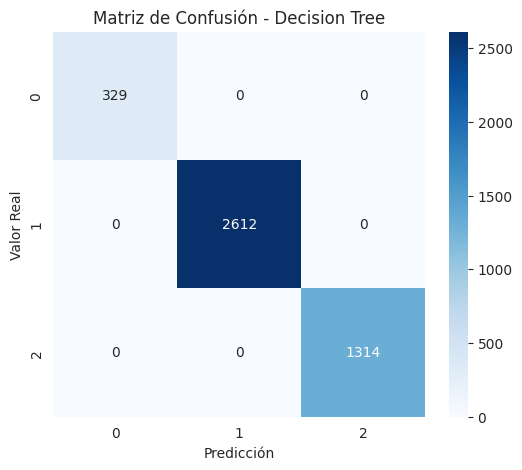

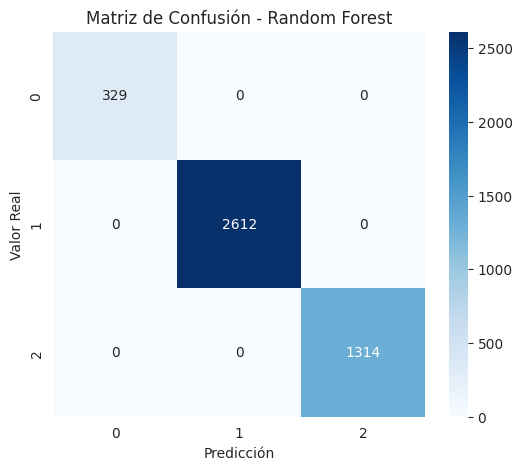

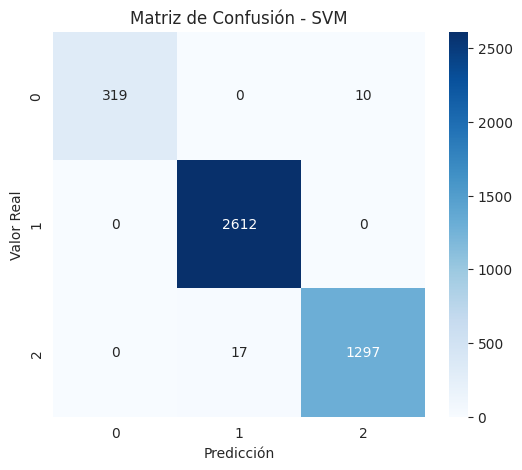

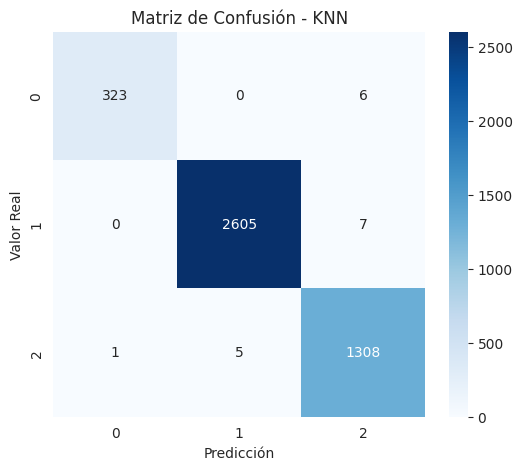

In [13]:

for model_name in results.keys():

    plt.figure(figsize=(6,5))

    cm = confusion_matrix(
        y_test,
        results[model_name]['predictions']
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Matriz de Confusión - {model_name}")

    plt.xlabel("Predicción")
    plt.ylabel("Valor Real")

    plt.show()



# Classification Report


In [14]:

for model_name in results.keys():

    print("="*70)
    print(f"MODELO: {model_name}")

    report = classification_report(
        y_test,
        results[model_name]['predictions'],
        target_names=encoder.classes_
    )

    print(report)


MODELO: Logistic Regression
                 precision    recall  f1-score   support

  High Activity       1.00      0.98      0.99       329
   Low Activity       0.99      1.00      1.00      2612
Medium Activity       1.00      0.98      0.99      1314

       accuracy                           0.99      4255
      macro avg       1.00      0.99      0.99      4255
   weighted avg       0.99      0.99      0.99      4255

MODELO: Decision Tree
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1.00      1.00      2612
Medium Activity       1.00      1.00      1.00      1314

       accuracy                           1.00      4255
      macro avg       1.00      1.00      1.00      4255
   weighted avg       1.00      1.00      1.00      4255

MODELO: Random Forest
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Ac


# Importancia de Variables

Se analiza la importancia de variables utilizando Random Forest.


In [15]:

# ========================================
# FEATURE IMPORTANCE
# ========================================

rf_model = results['Random Forest']['model']

importance = pd.DataFrame({
    'Variable': features,
    'Importancia': rf_model.named_steps['model'].feature_importances_
})

importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

importance


,Variable,Importancia
2,StepTotal_scaled,0.916297
0,Hora,0.083354
1,FinDeSemana,0.000349


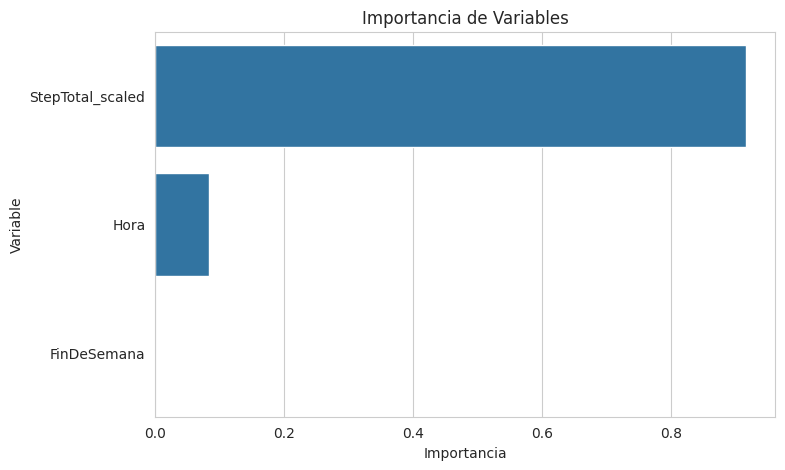

In [16]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importancia',
    y='Variable'
)

plt.title("Importancia de Variables")

plt.show()



# Interpretación Técnica

## Hallazgos principales
- Se implementaron cinco modelos supervisados.
- Los pipelines permiten automatizar el flujo de trabajo.
- Random Forest permite interpretar importancia de variables.
- Modelos escalados mejoran el rendimiento en algoritmos sensibles a magnitud.

## Comparación inicial
- Accuracy permite una comparación preliminar.
- Algunas clases presentan mayor dificultad de clasificación.
- La matriz de confusión permite detectar errores específicos.

## Posibles problemas detectados
- Riesgo de overfitting en modelos complejos.
- Posible desbalance de clases.
- Dependencia de ciertas variables predictoras.

## Próximos pasos
- Validación cruzada.
- Métricas avanzadas.
- Optimización de hiperparámetros.
- Comparación robusta de modelos.
